# Pavia University — EDA

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')

## Завантаження даних

In [2]:
mat_x = sio.loadmat('../data/Pavia/PaviaU.mat')
mat_y = sio.loadmat('../data/Pavia/PaviaU_gt.mat')

X = mat_x['paviaU'].astype(np.float32)   # (610, 340, 103)
y = mat_y['paviaU_gt'].astype(np.int32)  # (610, 340)

print('Куб даних X:', X.shape, '  dtype:', X.dtype)
print('Ground truth y:', y.shape, '  dtype:', y.dtype)

Куб даних X: (610, 340, 103)   dtype: float32
Ground truth y: (610, 340)   dtype: int32


## Базові параметри

In [3]:
H, W, C = X.shape
n_classes = len(np.unique(y)) - 1  # без фону (0)
total_pixels = H * W
labeled_pixels = int(np.sum(y > 0))
background_pixels = int(np.sum(y == 0))

print(f'Розміри сцени:       {H} x {W} пікселів')
print(f'Кількість каналів:   {C}')
print(f'Кількість класів:    {n_classes}')
print(f'Всього пікселів:     {total_pixels:,}')
print(f'Розмічених (не фон): {labeled_pixels:,} ({labeled_pixels/total_pixels*100:.1f}%)')
print(f'Фон (клас 0):        {background_pixels:,} ({background_pixels/total_pixels*100:.1f}%)')

Розміри сцени:       610 x 340 пікселів
Кількість каналів:   103
Кількість класів:    9
Всього пікселів:     207,400
Розмічених (не фон): 42,776 (20.6%)
Фон (клас 0):        164,624 (79.4%)


## Розподіл класів

In [4]:
CLASS_NAMES = {
    1: 'Asphalt',
    2: 'Meadows',
    3: 'Gravel',
    4: 'Trees',
    5: 'Painted metal sheets',
    6: 'Bare Soil',
    7: 'Bitumen',
    8: 'Self-Blocking Bricks',
    9: 'Shadows',
}

counts = {cls: int(np.sum(y == cls)) for cls in range(1, n_classes + 1)}

print(f'{"Клас":>4}  {"Назва":<25} {"Кількість":>10}  {"% від розмічених":>18}')
print('-' * 64)
for cls, cnt in counts.items():
    print(f'{cls:>4}  {CLASS_NAMES[cls]:<25} {cnt:>10,}  {cnt/labeled_pixels*100:>17.2f}%')

values = list(counts.values())
mode_cls = max(counts, key=counts.get)
min_cls  = min(counts, key=counts.get)
imbalance = counts[mode_cls] / counts[min_cls]

print(f'\nМода (найбільший клас): {mode_cls} — {CLASS_NAMES[mode_cls]} ({counts[mode_cls]:,} px)')
print(f'Мінімальний клас:       {min_cls} — {CLASS_NAMES[min_cls]} ({counts[min_cls]:,} px)')
print(f'Дисбаланс max/min:      {imbalance:.1f}x')
print(f'Середнє по класах:      {np.mean(values):.1f} px')
print(f'Медіана по класах:      {np.median(values):.1f} px')
print(f'Std по класах:          {np.std(values):.1f} px')

Клас  Назва                      Кількість    % від розмічених
----------------------------------------------------------------
   1  Asphalt                        6,631              15.50%
   2  Meadows                       18,649              43.60%
   3  Gravel                         2,099               4.91%
   4  Trees                          3,064               7.16%
   5  Painted metal sheets           1,345               3.14%
   6  Bare Soil                      5,029              11.76%
   7  Bitumen                        1,330               3.11%
   8  Self-Blocking Bricks           3,682               8.61%
   9  Shadows                          947               2.21%

Мода (найбільший клас): 2 — Meadows (18,649 px)
Мінімальний клас:       9 — Shadows (947 px)
Дисбаланс max/min:      19.7x
Середнє по класах:      4752.9 px
Медіана по класах:      3064.0 px
Std по класах:          5223.5 px


/var/folders/zq/0x5njn3506d3dlhny38q9tfm0000gn/T/ipykernel_93232/1068550466.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=9)


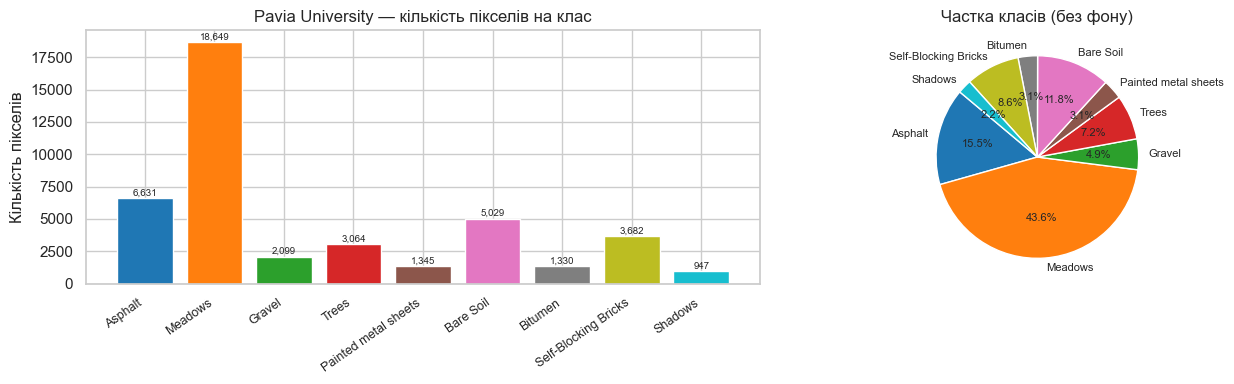

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
names  = [CLASS_NAMES[c] for c in counts]
vals   = list(counts.values())

bars = axes[0].bar(names, vals, color=colors, edgecolor='white')
axes[0].set_title('Pavia University — кількість пікселів на клас')
axes[0].set_ylabel('Кількість пікселів')
axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=9)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{v:,}', ha='center', va='bottom', fontsize=7)

axes[1].pie(vals, labels=names, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Частка класів (без фону)')

plt.tight_layout()
plt.show()

## Спектральні характеристики

Глобальні статистики по спектральних каналах:
  Min:  0.0
  Max:  8000.0
  Mean: 1389.13
  Std:  897.66


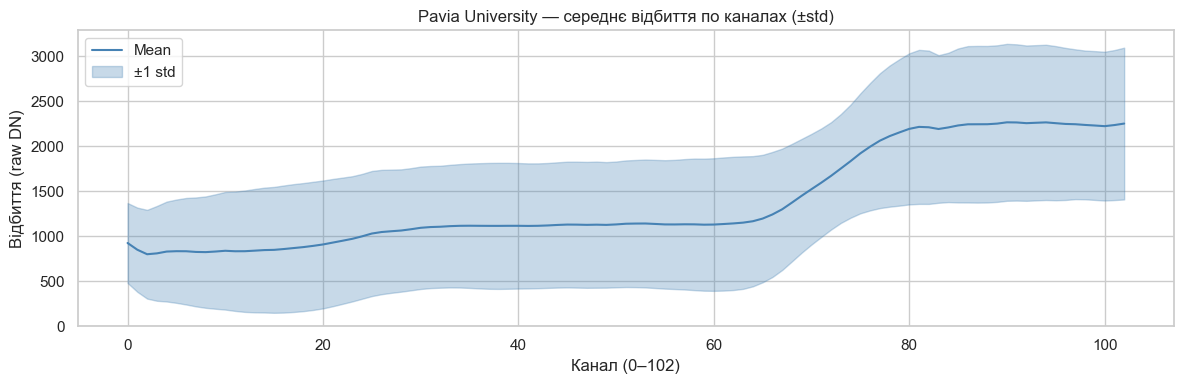

In [6]:
X_flat = X.reshape(-1, C)  # (207400, 103)
print('Глобальні статистики по спектральних каналах:')
print(f'  Min:  {X_flat.min():.1f}')
print(f'  Max:  {X_flat.max():.1f}')
print(f'  Mean: {X_flat.mean():.2f}')
print(f'  Std:  {X_flat.std():.2f}')

channel_means = X_flat.mean(axis=0)
channel_stds  = X_flat.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(channel_means, label='Mean', color='steelblue')
ax.fill_between(range(C),
                channel_means - channel_stds,
                channel_means + channel_stds,
                alpha=0.3, color='steelblue', label='±1 std')
ax.set_title('Pavia University — середнє відбиття по каналах (±std)')
ax.set_xlabel('Канал (0–102)')
ax.set_ylabel('Відбиття (raw DN)')
ax.legend()
plt.tight_layout()
plt.show()

## Спектральні сигнатури по класах

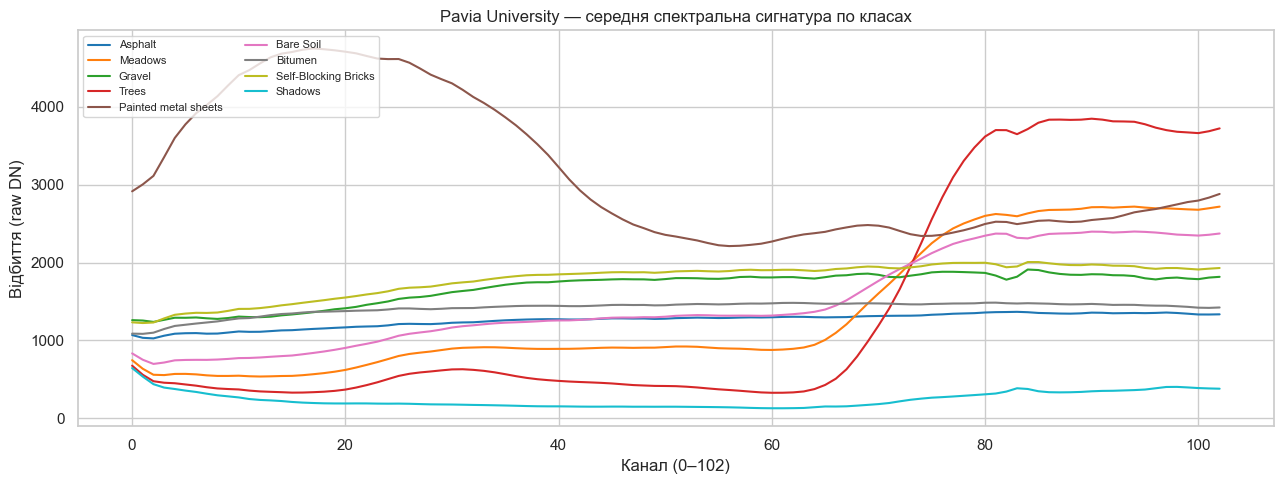

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for cls, color in zip(range(1, n_classes + 1), colors):
    mask = (y == cls)
    pixels = X[mask]          # (N_cls, 103)
    mean_sig = pixels.mean(axis=0)
    ax.plot(mean_sig, label=CLASS_NAMES[cls], color=color)

ax.set_title('Pavia University — середня спектральна сигнатура по класах')
ax.set_xlabel('Канал (0–102)')
ax.set_ylabel('Відбиття (raw DN)')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

## Ground truth map та false-color composite

/var/folders/zq/0x5njn3506d3dlhny38q9tfm0000gn/T/ipykernel_93232/827955870.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes + 1)


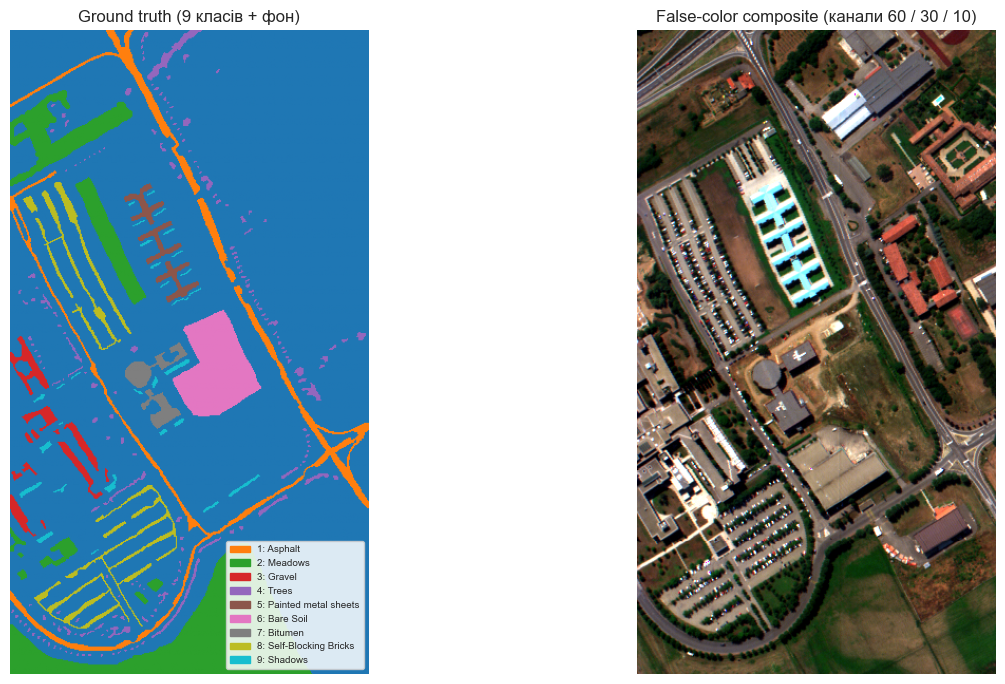

In [8]:
cmap = plt.cm.get_cmap('tab10', n_classes + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im = axes[0].imshow(y, cmap=cmap, vmin=0, vmax=n_classes)
axes[0].set_title('Ground truth (9 класів + фон)')
axes[0].axis('off')
patches = [mpatches.Patch(color=cmap(cls), label=f'{cls}: {CLASS_NAMES[cls]}')
           for cls in range(1, n_classes + 1)]
axes[0].legend(handles=patches, fontsize=7, loc='lower right',
               framealpha=0.85, ncol=1)

# False-color composite: ROSIS 430–860nm, 103 bands
# ~R: band 60 (~700nm), ~G: band 30 (~550nm), ~B: band 10 (~470nm)
rgb = X[:, :, [60, 30, 10]].copy()
for i in range(3):
    p2, p98 = np.percentile(rgb[:, :, i], (2, 98))
    rgb[:, :, i] = np.clip((rgb[:, :, i] - p2) / (p98 - p2 + 1e-8), 0, 1)
axes[1].imshow(rgb)
axes[1].set_title('False-color composite (канали 60 / 30 / 10)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Статистики по класах (min / mean / max / std)

In [9]:
print(f'{"Клас":<25} {"N px":>7}  {"Min":>8}  {"Mean":>8}  {"Max":>8}  {"Std":>8}')
print('-' * 70)
for cls in range(1, n_classes + 1):
    pixels = X[y == cls].flatten()
    print(f'{CLASS_NAMES[cls]:<25} {counts[cls]:>7,}  '
          f'{pixels.min():>8.1f}  {pixels.mean():>8.1f}  '
          f'{pixels.max():>8.1f}  {pixels.std():>8.1f}')

Клас                         N px       Min      Mean       Max       Std
----------------------------------------------------------------------
Asphalt                     6,631      32.0    1258.3    8000.0     301.2
Meadows                    18,649       0.0    1356.5    5571.0     912.8
Gravel                      2,099     327.0    1677.4    2629.0     298.7
Trees                       3,064       0.0    1380.2    7206.0    1472.2
Painted metal sheets        1,345     673.0    3154.4    6614.0    1212.2
Bare Soil                   5,029       0.0    1491.2    3891.0     759.3
Bitumen                     1,330     176.0    1412.9    2777.0     146.3
Self-Blocking Bricks        3,682     216.0    1780.2    2738.0     278.1
Shadows                       947       0.0     242.6    1978.0     149.8


## Кореляційна матриця каналів (sample 5000 px)

In [ ]:
rng = np.random.default_rng(42)
idx = rng.choice(X_flat.shape[0], size=5000, replace=False)
sample = X_flat[idx]  # (5000, 103)

# Покажемо кожен 5-й канал для читабельності
step = 5
sel = sample[:, ::step]   # (5000, ~21)
corr = np.corrcoef(sel.T)

tick_labels = [str(i) for i in range(0, C, step)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=tick_labels, yticklabels=tick_labels,
            linewidths=0.3)
ax.set_title('Кореляційна матриця (кожен 5-й канал)')
ax.set_xlabel('Канал')
ax.set_ylabel('Канал')
plt.tight_layout()
plt.show()

## Висновки

In [ ]:
print('=== Pavia University — підсумок EDA ===')
print(f'Розмір сцени:           {H}×{W} px, {C} каналів (ROSIS, 430–860 nm)')
print(f'Кількість класів:       {n_classes}')
print(f'Всього пікселів:        {total_pixels:,}')
print(f'Розмічено:              {labeled_pixels:,} ({labeled_pixels/total_pixels*100:.1f}%)')
print(f'Фон (клас 0):           {background_pixels:,} ({background_pixels/total_pixels*100:.1f}%)')
print()
print(f'Найбільший клас:        {CLASS_NAMES[mode_cls]} — {counts[mode_cls]:,} px ({counts[mode_cls]/labeled_pixels*100:.1f}%)')
print(f'Найменший клас:         {CLASS_NAMES[min_cls]} — {counts[min_cls]:,} px ({counts[min_cls]/labeled_pixels*100:.1f}%)')
print(f'Дисбаланс (max/min):    {imbalance:.1f}x')
print()
print('Особливості для навчання:')
print('  - Meadows (клас 2) домінує: 18649 px / ~45% розмітки')
print('  - Shadows (клас 9) найменший: 947 px / ~2.3%')
print('  - 79.4% пікселів — фон (не класифікується)')
print('  - WeightedRandomSampler або class-balanced loss критично важливі')
print('  - При 10 зразків на клас використовується ~0.5% наявної розмітки')